[[ True  True  True  True  True]
 [False  True False  True False]
 [ True  True  True False False]
 [False False  True False False]
 [ True False  True  True  True]]
0.6041


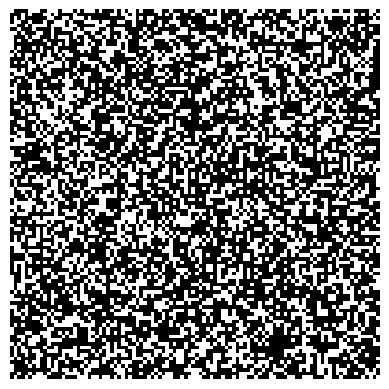

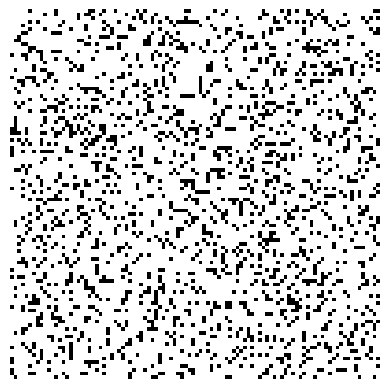

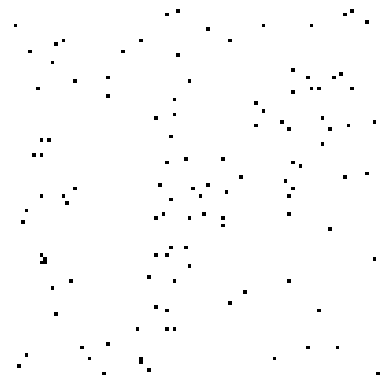

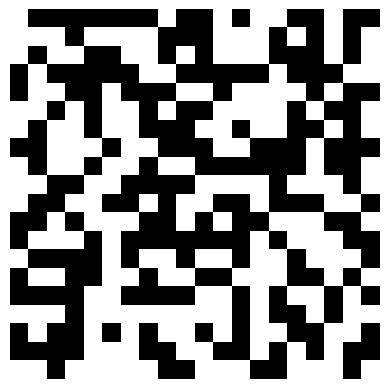

=== Test de la fonction voisins ===
Triangle (0,0): [(1, 0), (0, 1), (1, 1)]
Triangle (2,2): [(1, 2), (3, 2), (2, 1), (2, 3), (1, 1), (3, 3)]
Carrée (0,0): [(1, 0), (0, 1)]
Carrée (2,2): [(1, 2), (3, 2), (2, 1), (2, 3)]

=== Test de trouver_amas ===
[(0, 0), (1, 1), (0, 1)] taille de l'amas = 3
[(1, 3), (2, 3)] taille de l'amas = 2
[(3, 0)] taille de l'amas = 1

=== Test de percolation ===
Percolation verticale: True
Grille vide: False
Diagonale: True

=== Test pour différentes valeurs de p ===


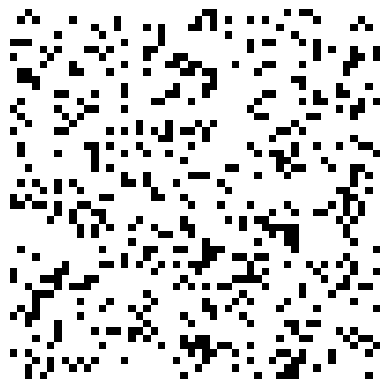

p= 0.2 Est ce qu'elle percole ? False


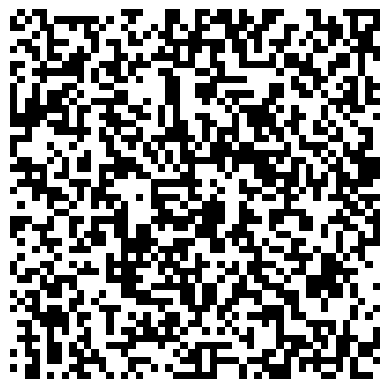

p= 0.5 Est ce qu'elle percole ? True


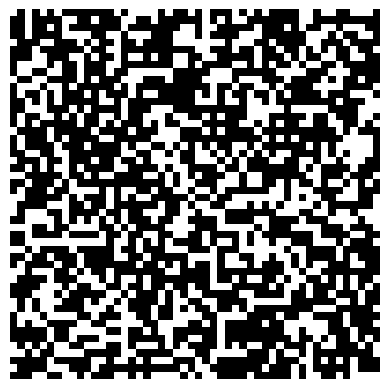

p= 0.6 Est ce qu'elle percole ? True


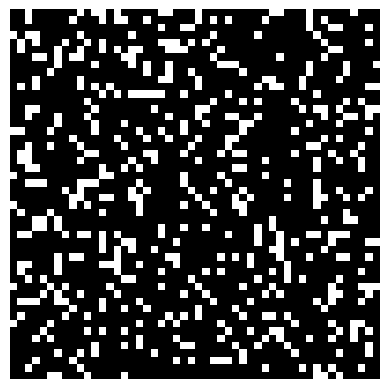

p= 0.8 Est ce qu'elle percole ? True

=== Test de proba_percolation ===
p=0.2 : 0.0
p=0.5 : 0.68
p=0.7 : 1.0

=== Calcul pour plusieurs valeurs de p ===
p= 0.0 probabilité de percolation= 0.0
p= 0.0101 probabilité de percolation= 0.0
p= 0.0202 probabilité de percolation= 0.0
p= 0.0303 probabilité de percolation= 0.0
p= 0.0404 probabilité de percolation= 0.0
p= 0.0505 probabilité de percolation= 0.0
p= 0.0606 probabilité de percolation= 0.0
p= 0.0707 probabilité de percolation= 0.0
p= 0.0808 probabilité de percolation= 0.0
p= 0.0909 probabilité de percolation= 0.0
p= 0.101 probabilité de percolation= 0.0
p= 0.1111 probabilité de percolation= 0.0
p= 0.1212 probabilité de percolation= 0.0
p= 0.1313 probabilité de percolation= 0.0
p= 0.1414 probabilité de percolation= 0.0
p= 0.1515 probabilité de percolation= 0.0
p= 0.1616 probabilité de percolation= 0.0
p= 0.1717 probabilité de percolation= 0.0
p= 0.1818 probabilité de percolation= 0.0
p= 0.1919 probabilité de percolation= 0.0
p= 0.202 pr

In [ ]:
#三角形情况下的Pc确定
import numpy as np
import matplotlib.pyplot as plt 
 
def generation_grille(N,p):
    grille = np.random.random((N,N)) < p
    return grille 

grille_test = generation_grille(5,0.6)
print(grille_test)

print(np.mean(generation_grille(100,0.6)))

def afficher_grille(grille):
    plt.imshow(grille, cmap = "gray_r")
    plt.axis("off")
    plt.show()

grille06 = generation_grille(100,0.6)
afficher_grille(grille06)

grille02 = generation_grille(100,0.2)
afficher_grille(grille02)

grille001 = generation_grille(100,0.01)
afficher_grille(grille001)

grille20_05 = generation_grille(20,0.5)
afficher_grille(grille20_05)


def voisins(i, j, N, forme='triangulaire'):
    voisins_valides = []
    if forme == 'triangulaire':
        candidats=[(i-1,j),(i+1,j),(i,j-1),(i,j+1),(i-1,j-1),(i+1,j+1)]
        for a, b in candidats:
            if 0 <= a < N and 0 <= b < N:
                voisins_valides.append((a, b))
        return voisins_valides
    
    if forme == 'carrée':
        candidats = [(i-1, j), (i+1, j), (i, j-1), (i, j+1)]
        voisins_valides = []
        
        for a, b in candidats:
            if 0 <= a < N and 0 <= b < N:
                voisins_valides.append((a, b))
        
        return voisins_valides

print("=== Test de la fonction voisins ===")
print("Triangle (0,0):", voisins(0,0,5,'triangulaire'))
print("Triangle (2,2):", voisins(2,2,5,'triangulaire'))
print("Carrée (0,0):", voisins(0,0,5,'carrée'))
print("Carrée (2,2):", voisins(2,2,5,'carrée'))


def exploration_amas(grille, depart, visites):
    N = grille.shape[0]
    pile = [depart]
    amas = []
    visites.add(depart)
    
    while pile:
        i, j = pile.pop()
        amas.append((i, j))
        
        for a, b in voisins(i, j, N): 
            if grille[a, b] and (a, b) not in visites:
                visites.add((a, b))
                pile.append((a, b))
    
    return amas

def trouver_amas(grille):
    N = grille.shape[0]
    visites = set()
    liste_amas = []
    
    for i in range(N):
        for j in range(N):
            if grille[i, j] and (i, j) not in visites:
                amas = exploration_amas(grille, (i, j), visites)
                liste_amas.append(amas)
    
    return liste_amas
print("\n=== Test de trouver_amas ===")
grille_test = np.array([[1,1,0,0],
                        [0,1,0,1],
                        [0,0,0,1],
                        [1,0,0,0]], dtype=bool)

amas = trouver_amas(grille_test)
for a in amas: 
    print(a, "taille de l'amas =", len(a))

def amas_percole_verticalement(amas, N):
    touche_haut = False
    touche_bas = False
    
    for i, j in amas:
        if i == 0:
            touche_haut = True
        if i == N-1:
            touche_bas = True
    
    return touche_haut and touche_bas


def amas_percole_horizontalement(amas, N):
    touche_gauche = False
    touche_droite = False
    
    for i, j in amas:
        if j == 0:
            touche_gauche = True
        if j == N-1:
            touche_droite = True
    
    return touche_gauche and touche_droite


def percole(grille):
    N = grille.shape[0]
    liste_amas = trouver_amas(grille)
    
    for amas in liste_amas:
        if amas_percole_verticalement(amas, N) or amas_percole_horizontalement(amas, N):
            return True
    
    return False

print("\n=== Test de percolation ===")

# Test vertical
grille_vert = np.array([[0,1,0,0,0],
                        [0,1,0,0,0],
                        [0,1,0,0,0],
                        [0,1,0,0,0],
                        [0,1,0,0,0]], dtype=bool)
print("Percolation verticale:", percole(grille_vert))

# Test non percolation
grille_non = np.zeros((5,5), dtype=bool)
print("Grille vide:", percole(grille_non))

grille_diag = np.array([[1,0,0,0,0],
                        [0,1,0,0,0],
                        [0,0,1,0,0],
                        [0,0,0,1,0],
                        [0,0,0,0,1]], dtype=bool)
print("Diagonale:", percole(grille_diag))

print("\n=== Test pour différentes valeurs de p ===")

pc_triangulaire = 0.5 

for p in [0.2, 0.5, 0.6, 0.8]:
    grille = generation_grille(50, p)
    afficher_grille(grille)
    print("p=", p, "Est ce qu'elle percole ?", percole(grille))


def proba_percolation(N, p, nb_repetitions):
    compteur_percolation = 0
    
    for k in range(nb_repetitions):
        grille = generation_grille(N, p)
        if percole(grille):
            compteur_percolation += 1
    
    proba = compteur_percolation / nb_repetitions
    return proba


# Test de la fonction proba_percolation
print("\n=== Test de proba_percolation ===")
N = 100
repets = 150

print("p=0.2 :", proba_percolation(N, 0.2, repets))
print("p=0.5 :", proba_percolation(N, 0.5, repets))  
print("p=0.7 :", proba_percolation(N, 0.7, repets))


print("\n=== Calcul pour plusieurs valeurs de p ===")
N = 100
repets = 150
valeurs_p = np.linspace(0, 1, 100)

probabilites = []

for p in valeurs_p:
    proba = proba_percolation(N, p, repets)
    probabilites.append(proba)
    print("p=", round(p, 4), "probabilité de percolation=", proba)


plt.plot(valeurs_p, probabilites)

plt.axvline(0.5, linestyle="--", label="seuil critique théorique (triangulaire, p_c=0.5)")

plt.xlabel("Probabilité d'occupation p")
plt.ylabel("Probabilité de percolation")
plt.title(f"Probabilité de percolation (réseau triangulaire) pour {N} x {N}, {repets} répétitions")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("\n=== Fin de la simulation ===")
print("Pour le réseau triangulaire, le seuil critique théorique est p_c = 0.5")
print("On observe bien une transition de phase autour de cette valeur.")

In [10]:

from scipy import optimize 
from scipy import optimize 
import numpy as np
import matplotlib.pyplot as plt

def n(s, A, tau): 
    return A * s ** (-tau)  

def distribution_amas(N, p):  
    grille = np.random.random((N, N)) < p  
    amas_list = trouver_amas(grille)  
    amas_len = [0 for i in range(N**2 + 1)]
    
    for i in amas_list: 
        taille = len(i)  
        if taille > 0:
            amas_len[taille] += 1
    x_data = [j for j in range(1, N**2 + 1) if amas_len[j] >= 2]
    y_data = [amas_len[j] for j in x_data]
    params, cov = optimize.curve_fit(n, x_data, y_data, p0=[1, 187/91])
    A_fit, tau_fit = params
    
    plt.figure()  
    plt.loglog(x_data, y_data, 'o', label='Données expérimentales')
    x_fit = np.array(x_data)
    y_fit = A_fit * x_fit ** (-tau_fit)
    plt.loglog(x_fit, y_fit, 'r-', label=f'Ajustement puissance tau={tau_fit:.3f}')
    plt.xlabel('Taille des amas')  
    plt.ylabel("Nombre d'amas")   
    plt.legend()
    plt.show()    
    
    tau_theorique = 187/91  
    print(f'Tau expérimental : {tau_fit:.4f}')
    print(f'Tau théorique (187/91) : {tau_theorique:.4f}')
    print(f'Incertitude relative : {abs(tau_fit - tau_theorique)/tau_theorique*100:.4f}%')

distribution_amas(200, 0.5)

IndexError: too many indices for array: array is 2-dimensional, but 3 were indexed

[[[False  True  True False  True]
  [ True  True  True False  True]
  [False False False  True False]
  [False  True  True False  True]
  [False  True False False False]]

 [[ True False  True  True  True]
  [False False False False False]
  [False  True  True  True  True]
  [ True  True  True  True False]
  [ True  True  True  True  True]]

 [[ True  True  True  True False]
  [False False False False  True]
  [ True  True  True  True False]
  [ True  True  True False  True]
  [ True False  True  True  True]]

 [[ True False False False  True]
  [ True  True  True  True False]
  [ True False  True  True False]
  [False  True  True False False]
  [ True  True False  True  True]]

 [[ True False False  True  True]
  [ True  True  True  True  True]
  [ True  True  True  True False]
  [False  True  True  True  True]
  [ True False False  True  True]]]
0.599461
=== Test de la fonction voisins (3D) ===
Voisins de (0,0,0) dans cube 5x5x5: [[0, 0, 1], [1, 0, 0], [0, 1, 0]]
Voisins de (2,2,2) d

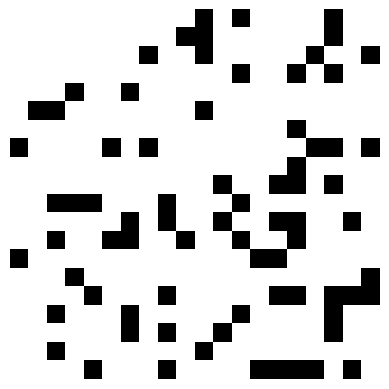

p= 0.3116 Est ce qu'elle percole ? False


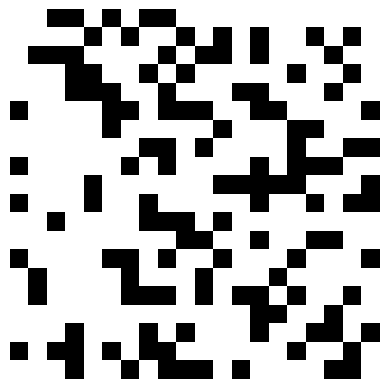

p= 0.4 Est ce qu'elle percole ? True


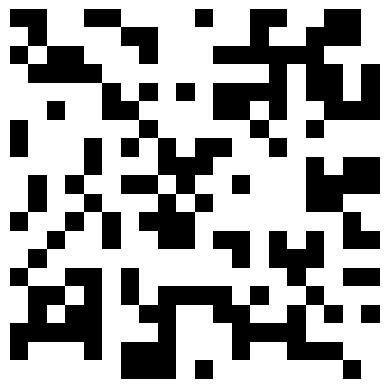

p= 0.6 Est ce qu'elle percole ? True


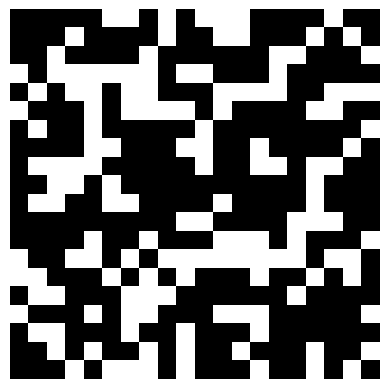


=== Test de proba_percolation 3D ===
p=0.2 : 0.0
p=0.3116 : 0.54
p=0.4 : 1.0

=== Calcul pour plusieurs valeurs de p (3D) ===
p= 0.1 probabilité de percolation= 0.0
p= 0.1051 probabilité de percolation= 0.0
p= 0.1101 probabilité de percolation= 0.0
p= 0.1152 probabilité de percolation= 0.0
p= 0.1202 probabilité de percolation= 0.0
p= 0.1253 probabilité de percolation= 0.0
p= 0.1303 probabilité de percolation= 0.0
p= 0.1354 probabilité de percolation= 0.0
p= 0.1404 probabilité de percolation= 0.0
p= 0.1455 probabilité de percolation= 0.0
p= 0.1505 probabilité de percolation= 0.0
p= 0.1556 probabilité de percolation= 0.0
p= 0.1606 probabilité de percolation= 0.0
p= 0.1657 probabilité de percolation= 0.0
p= 0.1707 probabilité de percolation= 0.0
p= 0.1758 probabilité de percolation= 0.0
p= 0.1808 probabilité de percolation= 0.0
p= 0.1859 probabilité de percolation= 0.0
p= 0.1909 probabilité de percolation= 0.0
p= 0.196 probabilité de percolation= 0.0
p= 0.201 probabilité de percolation= 

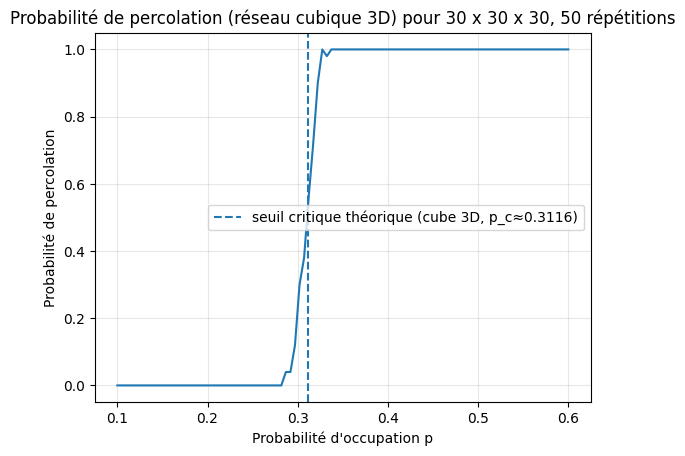


=== Fin de la simulation ===
Pour le réseau cubique 3D, le seuil critique théorique est p_c ≈ 0.3116
C'est la valeur pour la percolation de sites sur un réseau cubique simple.


In [7]:
import numpy as np
import matplotlib.pyplot as plt 

def generation_grille(N,p):
    grille = np.random.random((N,N,N)) < p
    return grille 

grille_test = generation_grille(5,0.6)
print(grille_test)

#verification de la proportion des sites occupés
print(np.mean(generation_grille(100,0.6)))


def afficher_grille(grille):

    plt.imshow(grille[:,:,0], cmap = "gray_r")
    plt.axis("off")
    plt.show()




def voisins(i, j, k, N, forme='cube'):
 
    voisin_valides = []    
 
    candidats = [[i, j, k+1], [i, j, k-1],  
                 [i-1, j, k], [i+1, j, k],  
                 [i, j-1, k], [i, j+1, k]]  
    
    for a, b, c in candidats:
        if 0 <= a < N and 0 <= b < N and 0 <= c < N:
            voisin_valides.append([a, b, c])
    
    return voisin_valides

print("=== Test de la fonction voisins (3D) ===")
print("Voisins de (0,0,0) dans cube 5x5x5:", voisins(0, 0, 0, 5))
print("Voisins de (2,2,2) dans cube 5x5x5:", voisins(2, 2, 2, 5))




def exploration_amas(grille, depart, visites):
 
    N = grille.shape[0]
    pile = [depart]
    amas = []
    visites.add(depart)
    
    while pile:
        i, j, k = pile.pop()
        amas.append((i, j, k))
        
        for a, b, c in voisins(i, j, k, N):
            if grille[a, b, c] and (a, b, c) not in visites:
                visites.add((a, b, c))
                pile.append((a, b, c))
    
    return amas



def trouver_amas(grille):
    N = grille.shape[0]
    visites = set()
    liste_amas = []
    
    for i in range(N):
        for j in range(N):
            for k in range(N):
                if grille[i, j, k] and (i, j, k) not in visites:
                    amas = exploration_amas(grille, (i, j, k), visites)
                    liste_amas.append(amas)
    
    return liste_amas




def amas_percole_direction_x(amas, N):
  
    touche_gauche = False
    touche_droite = False
    for i, j, k in amas:
        if i == 0:
            touche_gauche = True
        if i == N-1:
            touche_droite = True
    return touche_gauche and touche_droite


def amas_percole_direction_y(amas, N):
 
    touche_devant = False
    touche_derriere = False
    for i, j, k in amas:
        if j == 0:
            touche_devant = True
        if j == N-1:
            touche_derriere = True
    return touche_devant and touche_derriere


def amas_percole_direction_z(amas, N):
 
    touche_haut = False
    touche_bas = False
    for i, j, k in amas:
        if k == 0:
            touche_haut = True
        if k == N-1:
            touche_bas = True
    return touche_haut and touche_bas


def percole(grille):
    N = grille.shape[0]
    liste_amas = trouver_amas(grille)
    
    for amas in liste_amas:
        if amas_percole_direction_x(amas, N) or amas_percole_direction_y(amas, N) or amas_percole_direction_z(amas, N):
            return True
    
    return False




print("\n=== Test de percolation 3D ===")


grille_vert_3d = np.zeros((5,5,5), dtype=bool)
for k in range(5):
    grille_vert_3d[2, 2, k] = True  
print("Percolation verticale 3D:", percole(grille_vert_3d))

# 空网格
grille_non = np.zeros((5,5,5), dtype=bool)
print("Grille vide 3D:", percole(grille_non))


print("\n=== Test pour différentes valeurs de p (3D) ===")


pc_cube = 0.3116

for p in [0.2, 0.3116, 0.4, 0.6]:
    grille = generation_grille(20, p)
    print("p=", p, "Est ce qu'elle percole ?", percole(grille))
    if p in [0.2, 0.3116, 0.4, 0.6]:
        afficher_grille(grille)



def proba_percolation(N, p, nb_repetitions):
    """估计在给定 N 和 p 的情况下，网格发生渗流的概率"""
    compteur_percolation = 0
    
    for k in range(nb_repetitions):
        grille = generation_grille(N, p)
        if percole(grille):
            compteur_percolation += 1
    
    proba = compteur_percolation / nb_repetitions
    return proba


# Test de la fonction proba_percolation
print("\n=== Test de proba_percolation 3D ===")
N = 30
repets = 50

print("p=0.2 :", proba_percolation(N, 0.2, repets))
print("p=0.3116 :", proba_percolation(N, 0.3116, repets))
print("p=0.4 :", proba_percolation(N, 0.4, repets))




print("\n=== Calcul pour plusieurs valeurs de p (3D) ===")
N = 30
repets = 50
valeurs_p = np.linspace(0.1, 0.6, 100)

probabilites = []

for p in valeurs_p:
    proba = proba_percolation(N, p, repets)
    probabilites.append(proba)
    print("p=", round(p, 4), "probabilité de percolation=", proba)




plt.plot(valeurs_p, probabilites)


plt.axvline(0.3116, linestyle="--", label="seuil critique théorique (cube 3D, p_c≈0.3116)")

plt.xlabel("Probabilité d'occupation p")
plt.ylabel("Probabilité de percolation")
plt.title(f"Probabilité de percolation (réseau cubique 3D) pour {N} x {N} x {N}, {repets} répétitions")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("\n=== Fin de la simulation ===")
print("Pour le réseau cubique 3D, le seuil critique théorique est p_c ≈ 0.3116")
print("C'est la valeur pour la percolation de sites sur un réseau cubique simple.")

C:\Users\think\AppData\Local\Temp\ipykernel_12060\2575809651.py:4: RuntimeWarning: overflow encountered in power
  return A*s**(-tau)
C:\Users\think\AppData\Local\Temp\ipykernel_12060\2575809651.py:4: RuntimeWarning: overflow encountered in multiply
  return A*s**(-tau)


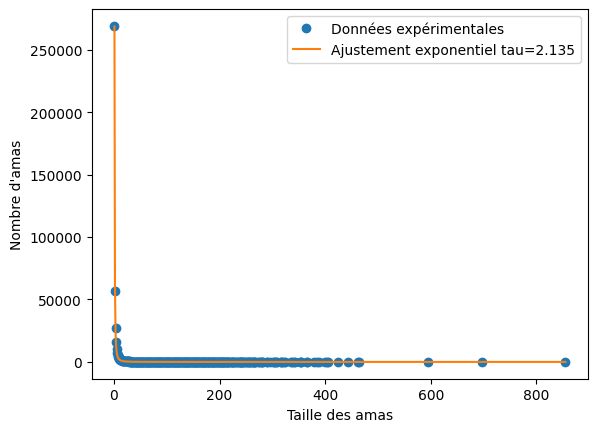

Tau est 2.1345353116954926 et 187/91≈ 2.0549450549450547


In [36]:
from scipy import optimize

def n(s,A,tau):
    return A*s**(-tau)

def distribution_amas(N,p):
    grille = np.random.random((N,N,N)) < p
    amas_list=trouver_amas(grille)
    amas_len=[0 for i in range(N**3 + 1)] 
    for i in amas_list:
        taille = len(i)  
        amas_len[taille] += 1  
    x_data = [j for j in range(1, N**3 + 1) if amas_len[j] >= 3]
    y_data = [amas_len[j] for j in x_data]
    params,cov=optimize.curve_fit(n, x_data, y_data, p0=[1.0, 187/91]) 
    plt.figure()
    plt.plot(x_data, y_data, 'o', label='Données expérimentales') 
    plt.plot(x_data, [n(i, params[0], params[1]) for i in x_data], label=f'Ajustement exponentiel tau={params[1]:.3f}')
    plt.xlabel('Taille des amas')
    plt.ylabel("Nombre d'amas")
    plt.legend()
    plt.show()
    tau=187/91
    print(f'Tau est {params[1]}','et 187/91≈',tau)
distribution_amas(200,0.3116)

[[False  True  True False  True]
 [False False  True  True False]
 [ True  True  True  True  True]
 [False  True  True False False]
 [False False  True False  True]]
0.5988


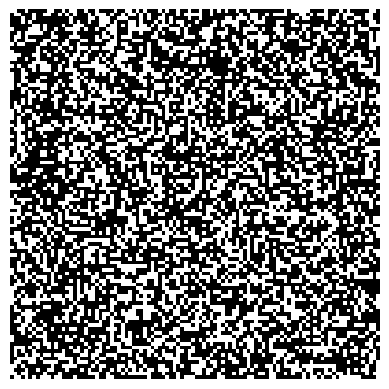

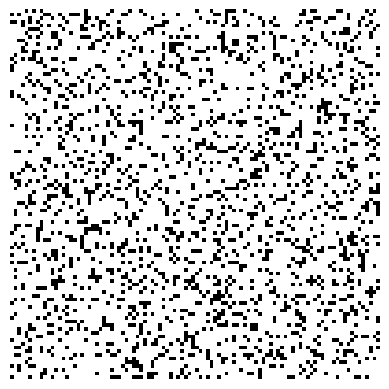

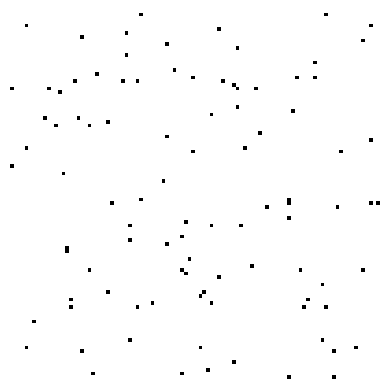

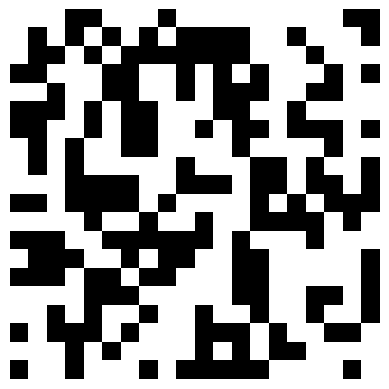

[(1, 0), (0, 1)]
[(1, 3), (3, 3), (2, 2), (2, 4)]
[(0, 0), (0, 1), (1, 1)] taille de l'amas = 3
[(1, 3), (2, 3)] taille de l'amas = 2
[(3, 0)] taille de l'amas = 1
True
False
False


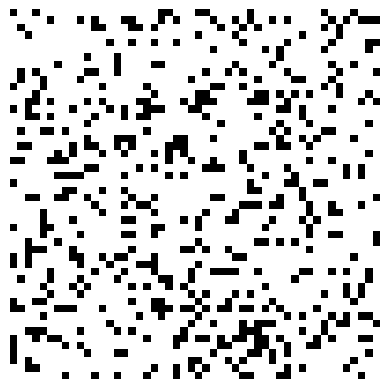

p= 0.2 Est ce qu'elle percole ? False


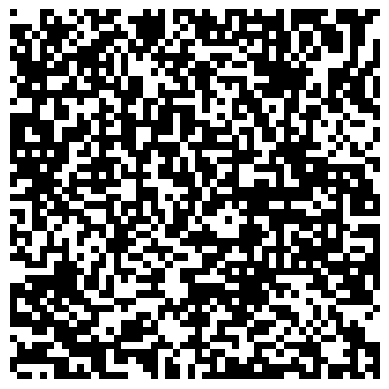

p= 0.6 Est ce qu'elle percole ? True


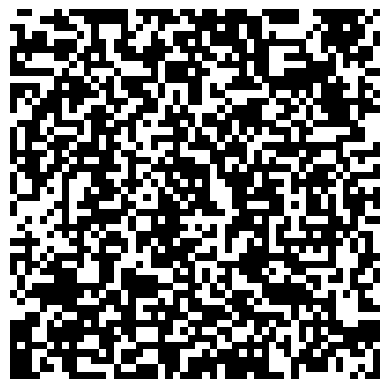

p= 0.592746 Est ce qu'elle percole ? True


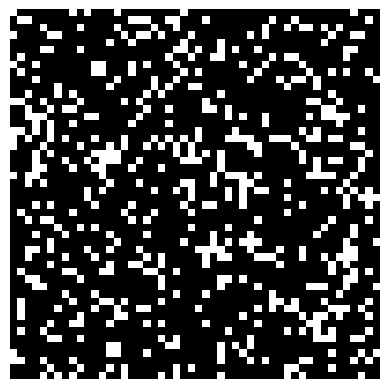

p= 0.8 Est ce qu'elle percole ? True
p=0.2 : 0.0
p=0.7 : 1.0
p= 0.0 probabilité de percolation= 0.0
p= 0.0101 probabilité de percolation= 0.0
p= 0.0202 probabilité de percolation= 0.0
p= 0.0303 probabilité de percolation= 0.0
p= 0.0404 probabilité de percolation= 0.0
p= 0.0505 probabilité de percolation= 0.0
p= 0.0606 probabilité de percolation= 0.0
p= 0.0707 probabilité de percolation= 0.0
p= 0.0808 probabilité de percolation= 0.0
p= 0.0909 probabilité de percolation= 0.0
p= 0.101 probabilité de percolation= 0.0
p= 0.1111 probabilité de percolation= 0.0
p= 0.1212 probabilité de percolation= 0.0
p= 0.1313 probabilité de percolation= 0.0
p= 0.1414 probabilité de percolation= 0.0
p= 0.1515 probabilité de percolation= 0.0
p= 0.1616 probabilité de percolation= 0.0
p= 0.1717 probabilité de percolation= 0.0
p= 0.1818 probabilité de percolation= 0.0
p= 0.1919 probabilité de percolation= 0.0
p= 0.202 probabilité de percolation= 0.0
p= 0.2121 probabilité de percolation= 0.0
p= 0.2222 probabilit

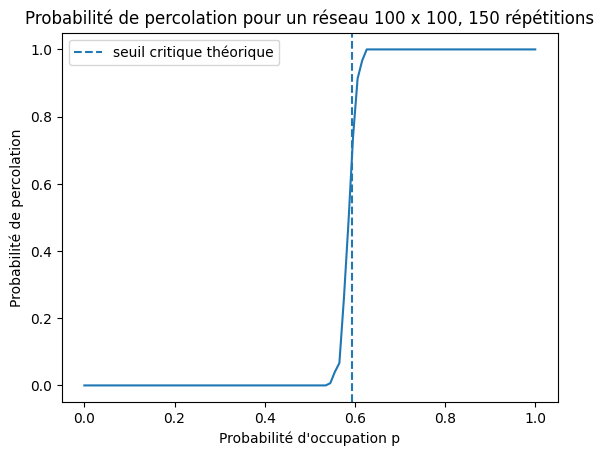

In [38]:
import numpy as np
import matplotlib.pyplot as plt 

#Création d'une matrice NxN avec des nombres aléatoires entre 0 et 1 
#puis transformation de la matrice en matrice de booléens grace à p. 

def generation_grille(N,p):
    grille = np.random.random((N,N)) < p
    return grille 

#test de la fonction generation de la grille avec N = 5, p = 0.6 

grille_test = generation_grille(5,0.6)
print(grille_test)

#verification de la proportion des sites occupés

print(np.mean(generation_grille(100,0.6)))

#Creation d'une fonction pour afficher la grille avec matplotlib

def afficher_grille(grille):
    plt.imshow(grille, cmap = "gray_r")
    plt.axis("off")
    plt.show()

#tester la génération de grille N = 100, p = 0.6

grille06 = generation_grille(100,0.6)
afficher_grille(grille06)

# génération de grille N = 100, p = 0.2

grille02 = generation_grille(100,0.2)
afficher_grille(grille02)

# génération de grille N = 100, p = 0.01

grille001 = generation_grille(100,0.01)
afficher_grille(grille001)

# génération de grille N = 20, p = 0.5

grille20_05 = generation_grille(20,0.5)
afficher_grille(grille20_05)

#fonction permettant de donner les voisins valides cad les voisins qui existent vraiment car aux frontieres de la grille on a pas forcement 4 voisins donc il faut que les voisins restent dans les coordonnes de la grille pour pouvoir etre comptes comme voisins. 
#Remarque : Je ne compte pas les voisins diagonaux car pas précisé dans l'énoncé

def voisins(i,j,N):
    candidats = [(i-1,j), (i+1,j), (i, j-1), (i,j+1)]
    voisins_valides = []

    for a, b in candidats:
        if 0 <= a < N and 0 <= b < N:
            voisins_valides.append((a,b))
    return voisins_valides

#Test de la fonction voisins sur un site à la frontière de la grille

print(voisins(0,0,5))

#sur une coordonnee aleatoire 

print(voisins(2,3,10))

#Coder une fonction pour explorer un amas

def exploration_amas(grille,depart,visites):
    N = grille.shape[0] #taille de la grille

    pile = [depart] #site de départ
    amas = [] #coordonnées des sites qui créent un amas avec le site depart

    visites.add(depart) #liste avec les sites déjà controlés pour ne pas les recontroler une seconde fois

    while pile: 
        i,j = pile.pop() 
        amas.append((i,j))

        for a,b in voisins(i,j,N): #controle des voisins du site observé
            if grille[a,b] and (a,b) not in visites: #test si le site voisin considéré et vide ou pas et si on l'a pas déjà controlé
                visites.add((a,b)) 
                pile.append((a,b))

    return amas
    

#Nous souhaitons maintenant détecter TOUS les amas présents dans la grille.

def trouver_amas(grille):
    N = grille.shape[0]
    visites = set() #creation d'un ensemble des sites déjà visités (ne contient pas de doublons, car set)
    liste_amas = [] #liste pour stocker les amas trouvés

    for i in range(N):
        for j in range(N): #pour chaque ligne i on parcourt toutes les colonnes j 
            if grille[i,j] and (i,j) not in visites: #vérifie si le site i,j est occupé ou non et s'il a déjà été visité ou non
                amas = exploration_amas(grille, (i,j),visites) #si c'est le cas, i,j et le début d'un nouvel amas et on utilise la fonction exploration_amas pour cartographier l'amas
                liste_amas.append(amas) #on ajoute l'amas cartographié de départ i,j à la liste qui repère les amas

    return liste_amas
  
#Test simple de la fonction trouver_amas

grille_test = np.array([[1,1,0,0],
                        [0,1,0,1],
                        [0,0,0,1],
                        [1,0,0,0]], dtype = bool)

amas = trouver_amas(grille_test)

for a in amas: 
    print(a, "taille de l'amas =", len(a))


#On souhaite désormais tester la percolation verticale (donc s'il existe un amas qui touche la ligne du haut et du bas), la percolation horizontale (donc si un amas touche la colonne de gauche et la colonne de droite), puis tester si la grille percole (donc soit on a percolation horizontale ou percolation verticale)

def amas_percole_verticalement(amas, N):
    touche_haut = False
    touche_bas = False

    for i, j in amas: 
        if i == 0:
            touche_haut = True
        if i == N-1:
            touche_bas = True
    
    return touche_haut and touche_bas

def amas_percole_horizontalement(amas, N):
    touche_gauche = False
    touche_droite = False

    for i, j in amas: 
        if j == 0:
            touche_gauche = True
        if j == N-1:
            touche_droite = True
    
    return touche_gauche and touche_droite


def percole(grille):
    N = grille.shape[0]
    liste_amas  = trouver_amas(grille)

    for amas in liste_amas:
        if amas_percole_verticalement(amas,N) or amas_percole_horizontalement(amas,N):
            return True
    
    return False


#Test d'une percolation evidente 

grille_vert = np.array([[0,1,0,0,0],
                        [0,1,0,0,0],
                        [0,1,0,0,0],
                        [0,1,0,0,0],
                        [0,1,0,0,0]], dtype=bool)

print(percole(grille_vert))

#Test d'une non percolation evidente 

grille_non = np.array([[0,0,0,0,0],
                        [0,0,0,0,0],
                        [0,0,0,0,0],
                        [0,0,0,0,0],
                        [0,0,0,0,0]], dtype=bool)

print(percole(grille_non))

#Test sur une diagonale (donc non percolante)

grille_diag = np.array([[1,0,0,0,0],
                        [0,1,0,0,0],
                        [0,0,1,0,0],
                        [0,0,0,1,0],
                        [0,0,0,0,1]], dtype = bool)

print(percole(grille_diag))


#On teste notre algorithme de détection de percolation sur des valeurs p différentes

pc = 0.592746

for p in [0.2,0.6,pc, 0.8]:
    grille = generation_grille(50,p)
    afficher_grille(grille)
    print("p=", p, "Est ce qu'elle percole ?", percole(grille))
  

#PARTIE 2 DU PROJET - étude de la percolation en fonctionde p pour N fixé 

# on va coder une fonction qui estime la proba de percolation pour un p donné
#pour cela on va créer : une liste de valeurs de p à tester, on calcule proba de perc pour chaque p et on fait un grafique puis une estimation numérique approx de p_c

#fonction qui estime la proba de percolation 

def proba_percolation(N,p,nb_repetitions):
    compteur_percolation = 0 

    for k in range(nb_repetitions):
        grille = generation_grille(N,p) #creations de grilles NxN à proba p aléatoires

        if percole(grille): #voir si les grilles percoles si oui on augmente le compteur
            compteur_percolation += 1

    proba = compteur_percolation/nb_repetitions
    return proba


#Test de la fonction proba_percolation

N=100
repets = 150

print("p=0.2 :", proba_percolation(N,0.2,repets))
print("p=0.7 :", proba_percolation(N,0.7,repets))


#calcul de la proba de percolation pour plusieurs valeurs de p 

N = 100
repets = 150
valeurs_p = np.linspace(0,1,100)

probabilites = []


for p in valeurs_p:
    proba = proba_percolation(N,p,repets)
    probabilites.append(proba)
    print("p=",round(p,4),"probabilité de percolation=", proba)


#tracer la courbe proba percolation en fonction de p 

plt.plot(valeurs_p, probabilites)
plt.axvline(0.592746, linestyle = "--", label = "seuil critique théorique")
plt.xlabel("Probabilité d'occupation p")
plt.ylabel("Probabilité de percolation")
plt.title(f"Probabilité de percolation pour un réseau {N} x {N}, {repets} répétitions")
plt.legend()
plt.show()

#On voit bien sur le graphique que la proba de percolation est nulle jusqu'à pas loin avant pc puis au seuil critique la proba augmente drastiquement et "saute" vers proba = 1 où elle se stabilise.


#on voit déjà sur la courbe que le seuil critique pc colle bien, on souhaite désormais estimer ce seuil critique à N fixé

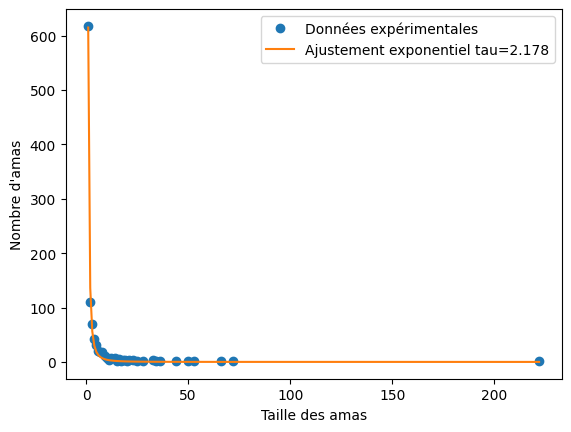

Tau est 2.1778301801554614 et 187/91≈ 2.0549450549450547


In [39]:
from scipy import optimize  # 从scipy库导入优化模块，用于曲线拟合

def n(s, A, tau):  # 定义幂律函数 n(s) = A * s^(-tau)
    return A * s ** (-tau)  # 返回幂律值，tau是正数时函数随s增大而减小

def distribution_amas(N, p):  # 定义函数：分析团簇大小分布，N=网格大小，p=占据概率
    grille = np.random.random((N, N)) < p  # 生成 N×N 的随机布尔网格，True=被占据
    amas_list = trouver_amas(grille)  # 找出网格中所有团簇，返回每个团簇的坐标列表
    
    amas_len = [0 for i in range(N**2 + 1)]  # 创建计数数组，索引=团簇大小，值=该大小的团簇数量
    # N**2 是网格总格子数，+1 是为了让索引等于大小（如 amas_len[5] 表示大小为5的团簇数量）
    
    for i in amas_list:  # 遍历每一个团簇
        taille = len(i)  # 获取当前团簇的大小（包含多少个格子）
        amas_len[taille] += 1  # 对应大小的团簇计数加1
    
    # ============================================================
    # 过滤小点：只保留出现次数 >= 3 的团簇大小
    # 为什么要这样做？
    # - 出现次数少（1次或2次）的团簇大小是统计噪声
    # - 这些点不服从幂律分布，会干扰拟合结果
    # - 排除它们可以让拟合更稳定、更准确
    # ============================================================
    x_data = [j for j in range(1, N**2 + 1) if amas_len[j] >= 2]  # 只保留计数≥2的团簇大小
    y_data = [amas_len[j] for j in x_data]  # 对应的计数作为y值
    
    # ============================================================
    # 进行幂律拟合
    # curve_fit 会找到最优的 A 和 tau，使得 n(s) 最接近实验数据
    # p0=[1.0, 187/91] 是初始猜测值：A=1.0, tau=187/91≈2.0549
    # ============================================================
    params, cov = optimize.curve_fit(n, x_data, y_data, p0=[1, 187/91])
    # params[0] = A（归一化常数）
    # params[1] = tau（幂律指数）
    # cov 是协方差矩阵，用于计算误差
    
    plt.figure()  # 创建新的图形窗口
    
    # 绘制实验数据点（散点图）
    plt.plot(x_data, y_data, 'o', label='Données expérimentales')
    
    # 绘制拟合曲线（根据拟合得到的参数计算）
    plt.plot(x_data, [n(i, params[0], params[1]) for i in x_data],
             label=f'Ajustement exponentiel tau={params[1]:.3f}')
    
    plt.xlabel('Taille des amas')  # X轴标签：团簇大小
    plt.ylabel("Nombre d'amas")    # Y轴标签：团簇数量
    plt.legend()  # 显示图例
    plt.show()    # 显示图形
    
    tau = 187/91  # 理论值 ≈ 2.0549（二维渗流的精确解）
    print(f'Tau est {params[1]}', 'et 187/91≈', tau)  # 打印拟合值和理论值

distribution_amas(200, 0.5988)  # 调用函数：100×100网格，p=0.5（三角形网格临界点附近）